# DESeq and WGCNA - all samples
In talks with TWL and SGW, I'm going to try and run DESeq on all samples (instead of splitting by phase 1 and 2) to get VST expression for everything, and then run WGCNA on phase 1 and 2 together. It'll be interesting to see what happens with the modules.

## 0. load libraries

In [70]:
# general
library(tidyverse)
library(ComplexHeatmap)
library(RColorBrewer)
library(janitor)

# DESeq
library(DESeq2)

# WGCNA
library(WGCNA)

## 1. read CSVs
for DESeq: 
- counts matrix: rows = genes, columns = samples
- meta data with treatment information

### counts matrix

In [4]:
counts <- read.csv('/work/pi_sarah_gignouxwolfsohn_uml_edu/julia/ce24_rnaseq/newRef_featureCounts/featureCounts_matrix.csv') %>%
select(-Length) %>%
column_to_rownames('Gene_ID')

head(counts)

,B1_B1_O01,B1_Nu_O03,B1_W5_O50,B2_B5_O51,B2_C4_O40,B2_Nu_O12,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,⋯,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_Nu_G41,W6_Nu_G45,W6_W3_G36,W6_W4_G48
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
LOC144621260,2626,2649,2072,2158,2074,3974,1207,1181,3017,1438,⋯,1252,2294,2215,1653,1720,1566,2734,2374,2683,2391
LOC144621269,55,580,1632,2484,1011,20011,2110,886,9991,1446,⋯,6,620,44,101,9226,16,2,4034,383,9803
LOC111120925,70,4,23,469,11,18,15,7,0,1,⋯,3,452,82,28,5,1,0,11,11,9
Trnae-cuc,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
Trnae-cuc-2,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
Trnae-cuc-3,0,0,0,0,0,1,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


### meta data

In [7]:
meta <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/metaData/sample_metaData.csv') %>%
mutate(complete_trtmt = paste0(Phase1_treatment, "_", Phase2_treatment)) %>%
column_to_rownames('Sample')

head(meta)

,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,complete_trtmt
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<chr>
B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,both_both
B1_Nu_O03,both,warm,hypoxic,1,NA,NA,NA,NA,both_NA
B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5,both_warm
B2_B5_O51,both,warm,hypoxic,2,both,warm,hypoxic,5,both_both
B2_C4_O40,both,warm,hypoxic,2,control,ambient,normoxic,4,both_control
B2_Nu_O12,both,warm,hypoxic,2,NA,NA,NA,NA,both_NA


### check order and sample names 

In [8]:
# setting the same order for counts matrix and meta data
counts.filtered <- counts[,rownames(meta)]
all(rownames(meta) == colnames(counts.filtered))

[1] TRUE

## 2. format CSVs for DESeq
pre-filtering counts matrix in the same way I have before: only keeping genes that have at least half of the samples with counts of 5 or higher

In [11]:
keep <- apply(counts.filtered, # raw counts matrix
              1, # apply across rows - for each row/gene, apply this function: 
              function(x) {
  any(tapply(x, meta$complete_trtmt, # split counts for this gene by treatment combo
             function(g) sum(g >= 5) >= 3)) # does this treatment combo have at least 3 samples with counts of 5 or more?
             # any = is at least one group true?
})

In [14]:
counts.ready <- counts.filtered[keep,]
head(counts.ready)

,B1_B1_O01,B1_Nu_O03,B1_W5_O50,B2_B5_O51,B2_C4_O40,B2_Nu_O12,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,⋯,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_Nu_G41,W6_Nu_G45,W6_W3_G36,W6_W4_G48
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
LOC144621260,2626,2649,2072,2158,2074,3974,1207,1181,3017,1438,⋯,1252,2294,2215,1653,1720,1566,2734,2374,2683,2391
LOC144621269,55,580,1632,2484,1011,20011,2110,886,9991,1446,⋯,6,620,44,101,9226,16,2,4034,383,9803
LOC111120925,70,4,23,469,11,18,15,7,0,1,⋯,3,452,82,28,5,1,0,11,11,9
LOC144621283,569,981,862,932,841,1079,704,933,1602,438,⋯,619,879,927,742,506,1279,1008,814,547,576
LOC144621276,11282,13770,10966,13117,12628,14439,11684,12683,19697,8706,⋯,11482,11309,8842,8855,13112,9109,15600,9444,9602,9409
LOC111115920,169,369,181,158,123,261,77,67,92,369,⋯,200,133,426,374,158,217,182,96,87,114


In [17]:
dim(counts.ready)[1]/dim(counts.filtered)[1] * 100

[1] 77.57131

so I retain 77.5% of genes after filerting

## 3. run DESeq

In [18]:
# creating DESeq2 object
dds <- DESeqDataSetFromMatrix(countData = counts.ready,
                              colData = meta,
                              design = ~ complete_trtmt)
dds

# running DESeq
dds <- DESeq(dds)

# list coefficients
resultsNames(dds)

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”


class: DESeqDataSet 
dim: 26299 120 
metadata(1): version
assays(1): counts
rownames(26299): LOC144621260 LOC144621269 ... LOC144621306
  LOC144621888
rowData names(0):
colnames(120): B1_B1_O01 B1_Nu_O03 ... W6_W3_G36 W6_W4_G48
colData names(9): Phase1_treatment Phase1_temp ... Phase2_TankRep
  complete_trtmt

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



[1] "Intercept"                                  
 [2] "complete_trtmt_both_control_vs_both_both"   
 [3] "complete_trtmt_both_hypoxic_vs_both_both"   
 [4] "complete_trtmt_both_NA_vs_both_both"        
 [5] "complete_trtmt_both_warm_vs_both_both"      
 [6] "complete_trtmt_control_both_vs_both_both"   
 [7] "complete_trtmt_control_control_vs_both_both"
 [8] "complete_trtmt_control_hypoxic_vs_both_both"
 [9] "complete_trtmt_control_NA_vs_both_both"     
[10] "complete_trtmt_control_warm_vs_both_both"   
[11] "complete_trtmt_hypoxic_both_vs_both_both"   
[12] "complete_trtmt_hypoxic_control_vs_both_both"
[13] "complete_trtmt_hypoxic_hypoxic_vs_both_both"
[14] "complete_trtmt_hypoxic_NA_vs_both_both"     
[15] "complete_trtmt_hypoxic_warm_vs_both_both"   
[16] "complete_trtmt_warm_both_vs_both_both"      
[17] "complete_trtmt_warm_control_vs_both_both"   
[18] "complete_trtmt_warm_hypoxic_vs_both_both"   
[19] "complete_trtmt_warm_NA_vs_both_both"        
[20] "complete_trtmt_warm_warm_vs_both_both"

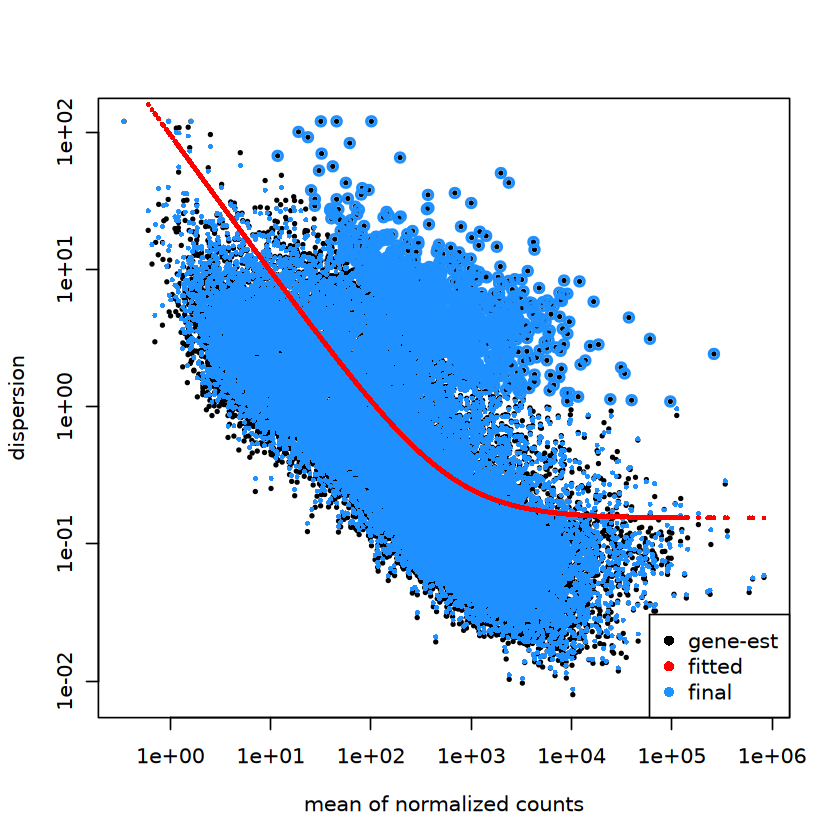

In [21]:
plotDispEsts(dds)

### outlier detection with NMDS

In [25]:
# normalization & transformation
vsd <- vst(dds)

# calculate sample distances
sample_dists <- assay(vsd) %>%
t() %>%
dist() %>%
as.matrix()

head(sample_dists)

# calculate MDS value from distance matrix
mdsData <- data.frame(cmdscale(sample_dists))
mds <- cbind(mdsData, as.data.frame(colData(vsd))) # combine with sample data

# add column to denote if phase 1 or 2 oyster
mds <- mds %>% 
mutate(phase = case_when(
    is.na(Phase2_treatment)  ~ 'Phase 1',
    .default    = 'Phase 2'))

head(mds)

,B1_B1_O01,B1_Nu_O03,B1_W5_O50,B2_B5_O51,B2_C4_O40,B2_Nu_O12,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,⋯,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_Nu_G41,W6_Nu_G45,W6_W3_G36,W6_W4_G48
B1_B1_O01,0.00000,78.33524,79.62662,82.91238,78.05743,99.28715,82.32599,81.07603,90.37839,81.95004,⋯,69.28567,73.08519,70.27489,73.39680,94.14957,76.67354,80.81734,84.64815,75.39360,98.74734
B1_Nu_O03,78.33524,0.00000,77.39430,86.92108,77.57731,96.84170,82.06187,83.50631,88.26661,82.76440,⋯,78.36835,78.31309,76.32474,76.94972,102.45040,76.59103,70.79071,78.44701,77.09105,98.91550
B1_W5_O50,79.62662,77.39430,0.00000,76.60284,67.63343,82.96768,63.32408,69.25886,70.89008,80.48619,⋯,78.38904,78.27187,80.96775,77.82159,83.00644,80.03389,78.29329,70.29382,75.41206,79.47175
B2_B5_O51,82.91238,86.92108,76.60284,0.00000,84.78971,89.15773,78.84521,83.89568,80.87007,90.86603,⋯,88.13502,76.33179,87.21076,89.05952,87.19904,89.61062,92.76914,87.11901,85.83264,82.34158
B2_C4_O40,78.05743,77.57731,67.63343,84.78971,0.00000,89.20118,71.23795,69.67709,79.10794,79.16124,⋯,76.61555,76.36384,77.53601,75.50997,90.45144,74.81270,75.85259,70.36616,60.59020,87.61049
B2_Nu_O12,99.28715,96.84170,82.96768,89.15773,89.20118,0.00000,81.22667,96.21828,79.74647,100.58159,⋯,103.64589,97.94996,102.43446,100.34863,72.44797,103.55867,99.15546,81.57863,93.75286,71.75788


,X1,X2,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,complete_trtmt,sizeFactor,phase
,<dbl>,<dbl>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<fct>,<dbl>,<chr>
B1_B1_O01,-13.039262,-12.174080,both,warm,hypoxic,1,both,warm,hypoxic,1,both_both,1.0395499,Phase 2
B1_Nu_O03,-16.145563,-5.007546,both,warm,hypoxic,1,NA,NA,NA,NA,both_NA,1.5069493,Phase 1
B1_W5_O50,4.155156,6.065439,both,warm,hypoxic,1,warm,warm,normoxic,5,both_warm,0.9935344,Phase 2
B2_B5_O51,15.976652,4.746735,both,warm,hypoxic,2,both,warm,hypoxic,5,both_both,1.0431258,Phase 2
B2_C4_O40,-2.582068,-4.769174,both,warm,hypoxic,2,control,ambient,normoxic,4,both_control,1.0980371,Phase 2
B2_Nu_O12,34.987042,27.363757,both,warm,hypoxic,2,NA,NA,NA,NA,both_NA,1.2965225,Phase 1


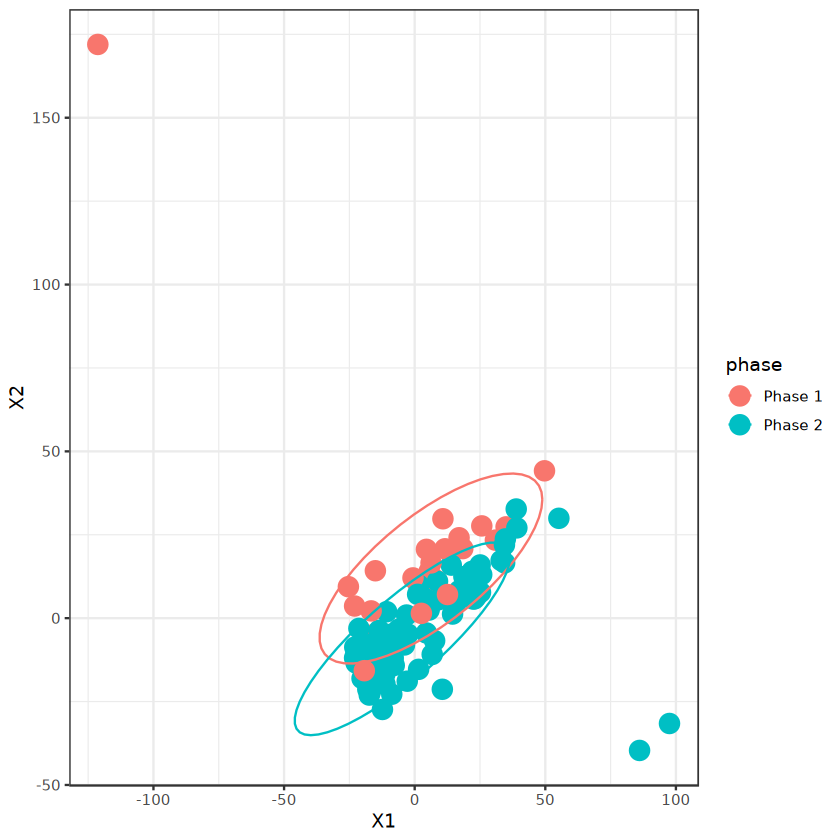

In [44]:
nmds.plot <- ggplot(mds, aes(X1, X2, col = phase)) +
geom_point(size = 5) +
stat_ellipse() + 
theme_bw()

nmds.plot

okay so we have some obvious outliers :
- B3_Nu_O24
- B5_C1_O09
- C1_C4_W37
- H2_H5_B51
- H6_Nu_B45
  
(are these the same samples I removed from the separate analyses? yes! except missing BH07 which I bet is the other outlier teal point that I couldn't get out of the filter below)

In [30]:
mds %>% filter(X1 < -50 | X1 > 48)

,X1,X2,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,complete_trtmt,sizeFactor,phase
,<dbl>,<dbl>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<fct>,<dbl>,<chr>
B3_Nu_O24,-121.29270,171.97631,both,warm,hypoxic,3,NA,NA,NA,NA,both_NA,0.03137397,Phase 1
B5_C1_O09,97.54034,-31.57340,both,warm,hypoxic,5,control,ambient,normoxic,1,both_control,0.62083471,Phase 2
C1_C4_W37,55.19661,29.93126,control,ambient,normoxic,1,control,ambient,normoxic,4,control_control,0.83845995,Phase 2
H2_H5_B51,86.08071,-39.65431,hypoxic,ambient,hypoxic,2,hypoxic,ambient,hypoxic,5,hypoxic_hypoxic,0.69950893,Phase 2
H6_Nu_B45,49.69358,44.16764,hypoxic,ambient,hypoxic,6,NA,NA,NA,NA,hypoxic_NA,0.97192123,Phase 1


### heatmap sample-to-sample distance

In [48]:
# normalization & transformation
vsd <- vst(dds)

# calculate sample distances
sample_dists <- dist(t(assay(dds)))
head(sample_dists)

[1]  882993.8  559109.6  658790.0  525934.1 2780197.2  551767.4

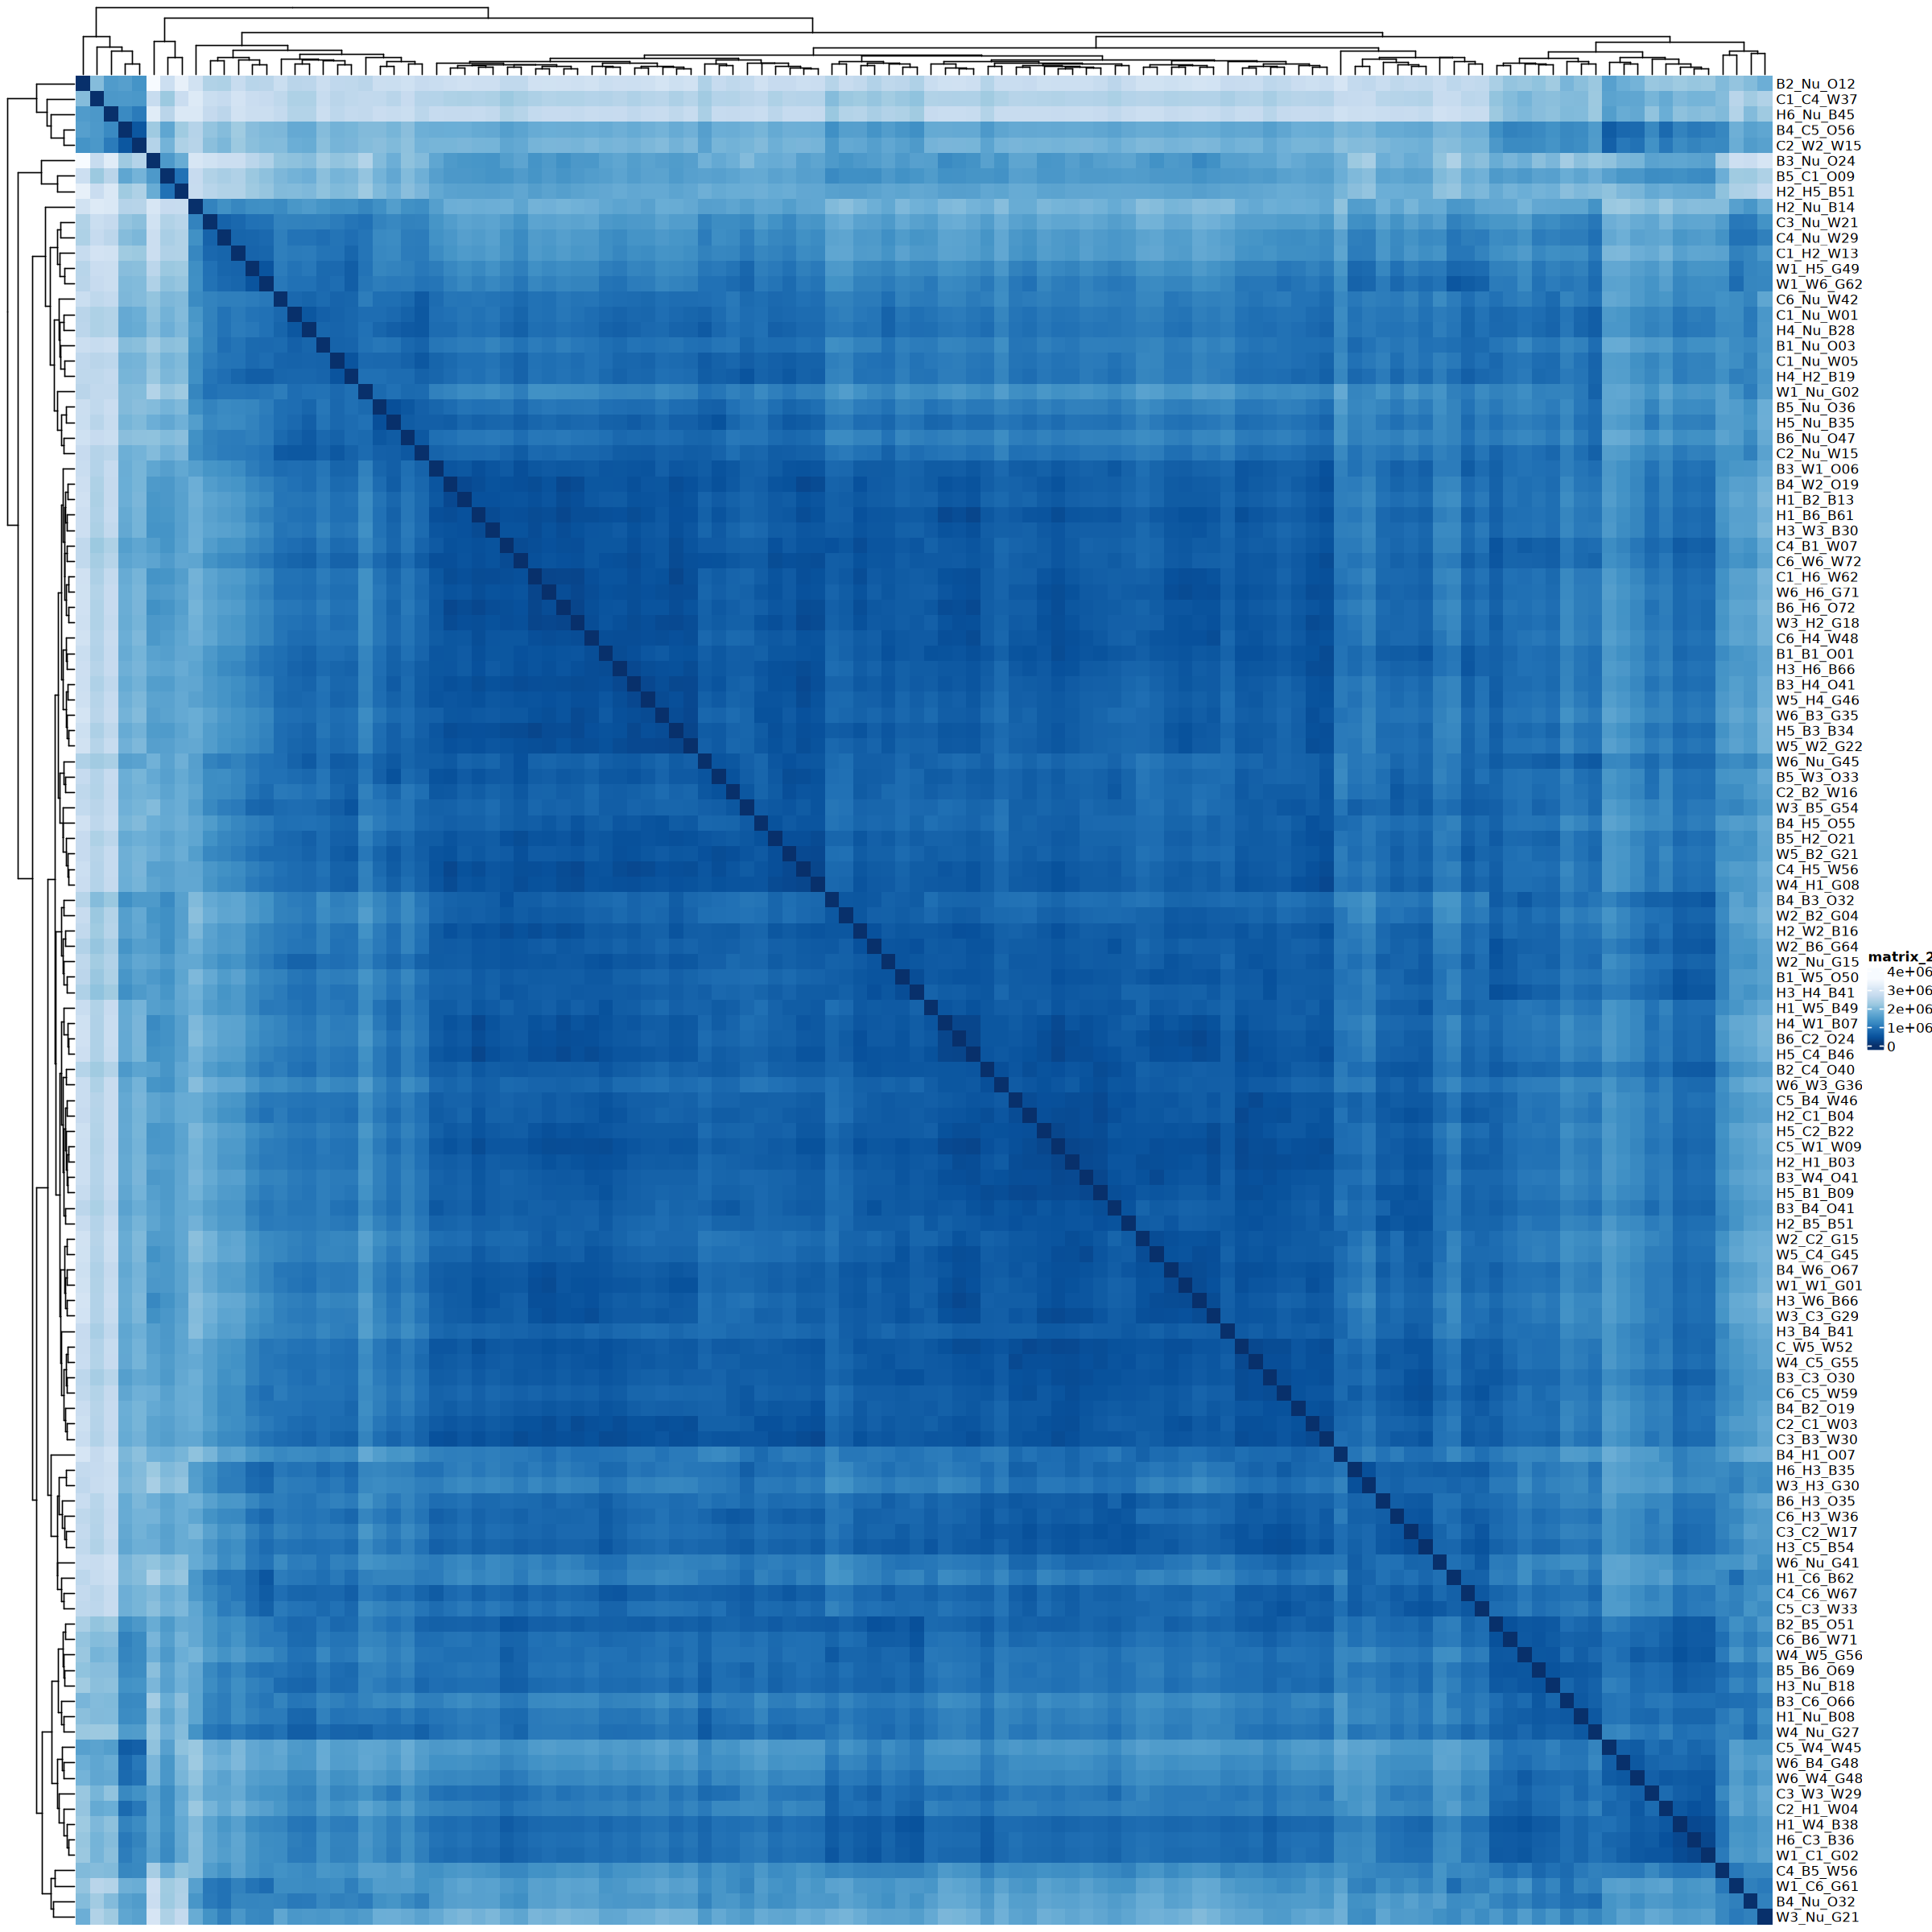

In [49]:
options(repr.plot.width=20, repr.plot.height=20)

sampleDistMatrix <- as.matrix(sample_dists)
rownames(sampleDistMatrix) <- paste(colnames(vsd))
colnames(sampleDistMatrix) <- NULL
colors <- colorRampPalette( rev(brewer.pal(9, "Blues")) )(255)
pheatmap(sampleDistMatrix,
         clustering_distance_rows = sample_dists,
         clustering_distance_cols = sample_dists,
         col = colors)

### remove outlier samples and rerun deseq

In [75]:
# remove outlier samples
outlier_samples <- c('B3_Nu_O24', 'B5_C1_O09', 'C1_C4_W37', 'H2_H5_B51', 'H6_Nu_B45', 'B4_H1_O07')
dds_rm <- dds[, !colnames(dds) %in% outlier_samples]

# rerun deseq
dds_rm <- DESeq(dds_rm)

using pre-existing size factors

estimating dispersions

found already estimated dispersions, replacing these

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



### vst expression

In [76]:
# run vst on new dds object
vst_mat <- assay(vst(dds_rm, blind = FALSE))
head(vst_mat)

,B1_B1_O01,B1_Nu_O03,B1_W5_O50,B2_B5_O51,B2_C4_O40,B2_Nu_O12,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,⋯,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_Nu_G41,W6_Nu_G45,W6_W3_G36,W6_W4_G48
LOC144621260,11.666953,11.269656,11.453130,11.444343,11.345947,11.890737,11.034822,11.041739,11.436993,11.102910,⋯,11.162800,11.57553,11.467739,11.269554,11.435389,11.280532,11.471606,11.572800,11.901560,11.714980
LOC144621269,9.122483,9.978336,11.198837,11.600233,10.642966,13.983392,11.629168,10.766306,12.883508,11.108529,⋯,8.793511,10.32771,9.065006,9.343892,13.522189,8.903466,8.682617,12.194809,10.069397,13.496908
LOC111120925,9.189670,8.710781,8.943717,10.081693,8.823398,8.864449,8.896728,8.803116,8.591124,8.666042,⋯,8.734292,10.09588,9.235584,8.990707,8.770431,8.669352,8.591124,8.831908,8.852397,8.822230
LOC144621283,10.221698,10.353835,10.591036,10.616577,10.485275,10.555235,10.537629,10.814204,10.796697,10.090774,⋯,10.505011,10.61570,10.607791,10.510067,10.295269,11.071990,10.502580,10.518313,10.329065,10.334013
LOC144621276,13.503236,13.272327,13.526015,13.702913,13.581633,13.538128,13.802742,13.954562,13.791216,13.260301,⋯,13.902072,13.57964,13.166142,13.312381,14.001776,13.436827,13.650792,13.287784,13.530107,13.441619
LOC111115920,9.512109,9.712293,9.564160,9.481098,9.359553,9.612035,9.278306,9.242035,9.168801,9.976553,⋯,9.730705,9.43289,10.013911,9.999569,9.580243,9.715006,9.451265,9.296234,9.319159,9.403732


In [77]:
write.csv(vst_mat, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/compare_phases/vst_allSamples.csv')

In [78]:
# normalization & transformation
vsd <- vst(dds_rm)

# calculate sample distances
sample_dists <- assay(vsd) %>%
t() %>%
dist() %>%
as.matrix()

head(sample_dists)

# calculate MDS value from distance matrix
mdsData <- data.frame(cmdscale(sample_dists))
mds <- cbind(mdsData, as.data.frame(colData(vsd))) # combine with sample data

# add column to denote if phase 1 or 2 oyster
mds <- mds %>% 
mutate(phase = case_when(
    is.na(Phase2_treatment)  ~ 'Phase 1',
    .default    = 'Phase 2'))

head(mds)

,B1_B1_O01,B1_Nu_O03,B1_W5_O50,B2_B5_O51,B2_C4_O40,B2_Nu_O12,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,⋯,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_Nu_G41,W6_Nu_G45,W6_W3_G36,W6_W4_G48
B1_B1_O01,0.00000,82.22305,83.73549,87.14256,82.02279,104.04266,86.47822,85.09442,94.87893,86.25592,⋯,72.67990,76.78391,73.87023,77.21185,98.57491,80.50355,84.76606,88.93292,79.20080,103.50986
B1_Nu_O03,82.22305,0.00000,81.27450,91.30988,81.38657,101.28465,85.99116,87.44969,92.59699,86.93677,⋯,82.10769,82.17550,80.18447,80.75208,107.09780,80.30601,74.27208,82.42833,80.78337,103.56531
B1_W5_O50,83.73549,81.27450,0.00000,80.68677,71.01367,86.88501,66.54800,72.72812,74.51473,84.56544,⋯,82.40443,82.25209,85.07923,81.75559,86.92032,84.04306,82.21888,73.66710,79.24787,83.36158
B2_B5_O51,87.14256,91.30988,80.68677,0.00000,89.03340,93.46083,82.92223,88.24055,85.03665,95.52377,⋯,92.69185,80.13018,91.57534,93.60236,91.40155,94.13710,97.39505,91.37005,90.13069,86.27626
B2_C4_O40,82.02279,81.38657,71.01367,89.03340,0.00000,93.39223,74.69342,73.09950,83.01458,83.18380,⋯,80.48500,80.20760,81.47286,79.29617,94.66831,78.56124,79.72456,73.82609,63.75541,91.82125
B2_Nu_O12,104.04266,101.28465,86.88501,93.46083,93.39223,0.00000,85.11512,100.74993,83.55793,105.32315,⋯,108.48490,102.47721,107.22105,105.05546,76.10196,108.30400,103.75925,85.38341,98.18474,75.41173


,X1,X2,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,complete_trtmt,sizeFactor,phase
,<dbl>,<dbl>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<fct>,<dbl>,<chr>
B1_B1_O01,-17.660717,-7.055364,both,warm,hypoxic,1,both,warm,hypoxic,1,both_both,1.0395499,Phase 2
B1_Nu_O03,-14.622997,-8.092850,both,warm,hypoxic,1,NA,NA,NA,NA,both_NA,1.5069493,Phase 1
B1_W5_O50,10.998580,12.621468,both,warm,hypoxic,1,warm,warm,normoxic,5,both_warm,0.9935344,Phase 2
B2_B5_O51,18.015797,-1.641187,both,warm,hypoxic,2,both,warm,hypoxic,5,both_both,1.0431258,Phase 2
B2_C4_O40,-1.425431,12.866465,both,warm,hypoxic,2,control,ambient,normoxic,4,both_control,1.0980371,Phase 2
B2_Nu_O12,50.727789,8.980655,both,warm,hypoxic,2,NA,NA,NA,NA,both_NA,1.2965225,Phase 1


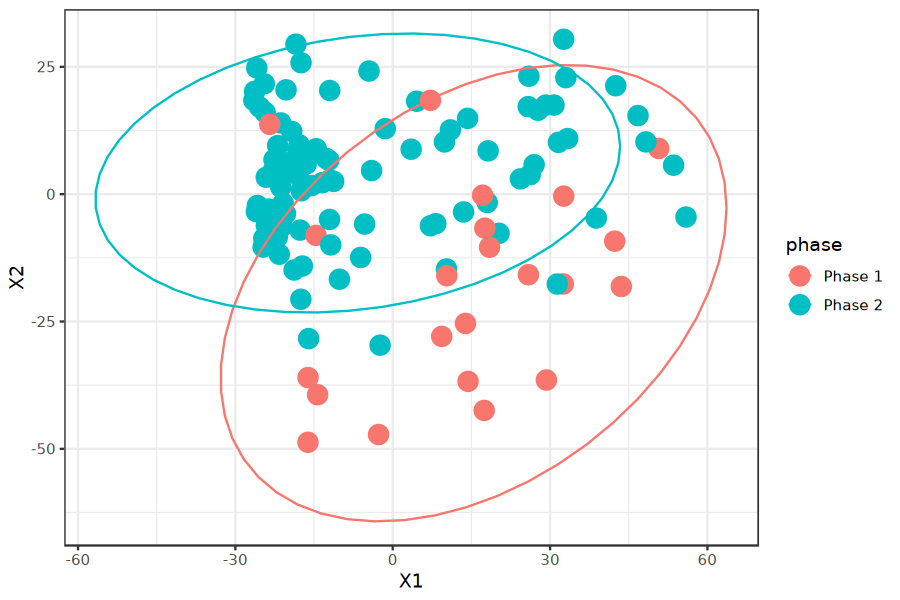

In [79]:
options(repr.plot.height = 5, repr.plot.width = 7.5)

nmds.plot <- ggplot(mds, aes(X1, X2, col = phase)) +
geom_point(size = 5) +
stat_ellipse() + 
theme_bw()

nmds.plot

seems like age of the sample has a big effect on transcriptional profiles - there's a pretty nice clustering of phase 1 and phase 2 oysters

## 4. WGCNA

In [80]:
# important setting, cannot omit
options(stringsAsFactors = FALSE)

In [81]:
# allow multi-threading within WGCNA
enableWGCNAThreads()

Allowing parallel execution with up to 35 working processes.


### 1. structure WGCNA input

**Expected input**:
- Rows = samples
- Columns = genes (or probes/features)
- Values = numeric expression values

#### A. format vst normalized counts matrix

In [82]:
dataExpr <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/compare_phases/vst_allSamples.csv') %>%
t()
head(dataExpr)

X,LOC144621260,LOC144621269,LOC111120925,LOC144621283,LOC144621276,LOC111115920,LOC144621308,LOC111112629,LOC111102827,LOC111102829,⋯,LOC111110910,LOC111110817,LOC111111216,LOC111111215,LOC111111213,LOC111114497,LOC111114498,LOC111112304,LOC144621306,LOC144621888
B1_B1_O01,11.666953,9.122483,9.189670,10.221698,13.503236,9.512109,9.141243,9.618407,10.873587,9.889120,⋯,10.305581,9.925308,9.440448,9.871433,13.576370,9.325028,11.649530,10.912403,8.794755,8.735172
B1_Nu_O03,11.269656,9.978336,8.710781,10.353835,13.272327,9.712293,8.986853,9.760261,10.976842,9.816409,⋯,10.458942,9.419664,9.839532,9.478724,13.542435,9.467267,11.677753,10.656562,8.591124,9.246491
B1_W5_O50,11.453130,11.198837,8.943717,10.591036,13.526015,9.564160,8.812020,10.047886,10.259356,9.922272,⋯,11.091223,9.248750,9.696171,9.594694,13.321229,9.385081,11.802117,10.873983,8.979950,8.785978
B2_B5_O51,11.444343,11.600233,10.081693,10.616577,13.702913,9.481098,9.153930,9.546623,11.335432,10.001400,⋯,11.212399,10.440866,9.576324,9.683796,13.751194,9.564075,11.881022,10.641642,8.591124,8.904048
B2_C4_O40,11.345947,10.642966,8.823398,10.485275,13.581633,9.359553,8.904047,10.364994,10.367171,9.873188,⋯,10.421410,9.152806,9.598530,9.488026,13.375409,9.451180,11.458404,10.885772,8.871120,8.904047


In [83]:
# counts matrix - sample x gene name
dataExpr <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/compare_phases/vst_allSamples.csv') %>%
  t() %>%
  as.data.frame() %>%
  row_to_names(row_number = 1, remove_row = TRUE)


# Convert all expression values to numeric
dataExpr <- dataExpr %>%
  mutate(across(everything(), as.numeric))

dim(dataExpr)
head(dataExpr)

[1]   114 26299

,LOC144621260,LOC144621269,LOC111120925,LOC144621283,LOC144621276,LOC111115920,LOC144621308,LOC111112629,LOC111102827,LOC111102829,⋯,LOC111110910,LOC111110817,LOC111111216,LOC111111215,LOC111111213,LOC111114497,LOC111114498,LOC111112304,LOC144621306,LOC144621888
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
B1_B1_O01,11.66695,9.122483,9.189670,10.22170,13.50324,9.512109,9.141243,9.618407,10.87359,9.889120,⋯,10.305581,9.925308,9.440448,9.871433,13.57637,9.325028,11.64953,10.91240,8.794755,8.735172
B1_Nu_O03,11.26966,9.978336,8.710781,10.35384,13.27233,9.712293,8.986853,9.760261,10.97684,9.816409,⋯,10.458942,9.419664,9.839532,9.478724,13.54243,9.467267,11.67775,10.65656,8.591124,9.246491
B1_W5_O50,11.45313,11.198837,8.943717,10.59104,13.52601,9.564160,8.812020,10.047886,10.25936,9.922272,⋯,11.091223,9.248750,9.696171,9.594694,13.32123,9.385081,11.80212,10.87398,8.979950,8.785978
B2_B5_O51,11.44434,11.600233,10.081693,10.61658,13.70291,9.481098,9.153930,9.546623,11.33543,10.001400,⋯,11.212399,10.440866,9.576324,9.683796,13.75119,9.564075,11.88102,10.64164,8.591124,8.904048
B2_C4_O40,11.34595,10.642966,8.823398,10.48527,13.58163,9.359553,8.904047,10.364994,10.36717,9.873188,⋯,10.421410,9.152806,9.598530,9.488026,13.37541,9.451180,11.45840,10.88577,8.871120,8.904047
B2_Nu_O12,11.89074,13.983392,8.864449,10.55523,13.53813,9.612035,8.943635,10.126716,11.16500,9.850764,⋯,9.504089,9.332586,10.010147,10.101586,13.75617,9.919905,11.97661,10.90341,9.181830,8.893196


#### B. identify and remove genes with missing data 
genes with too many NAs or zero-counts

In [84]:
gsg <- goodSamplesGenes(dataExpr, verbose = 3)
gsg$allOK

dataExpr <- dataExpr[gsg$goodSamples, gsg$goodGenes]
dim(dataExpr) # 23 samples x 28705 genes

 Flagging genes and samples with too many missing values...
  ..step 1


[1] TRUE

[1]   114 26299

#### C. Sample size and gene filtering

removing low-variance genes first:

In [85]:
dataExpr <- dataExpr[, apply(dataExpr, 2, var) > quantile(apply(dataExpr, 2, var), 0.25)]
dim(dataExpr) # 23 samples x 18897 genes

[1]   114 19724

#### D. Sample outlier detection

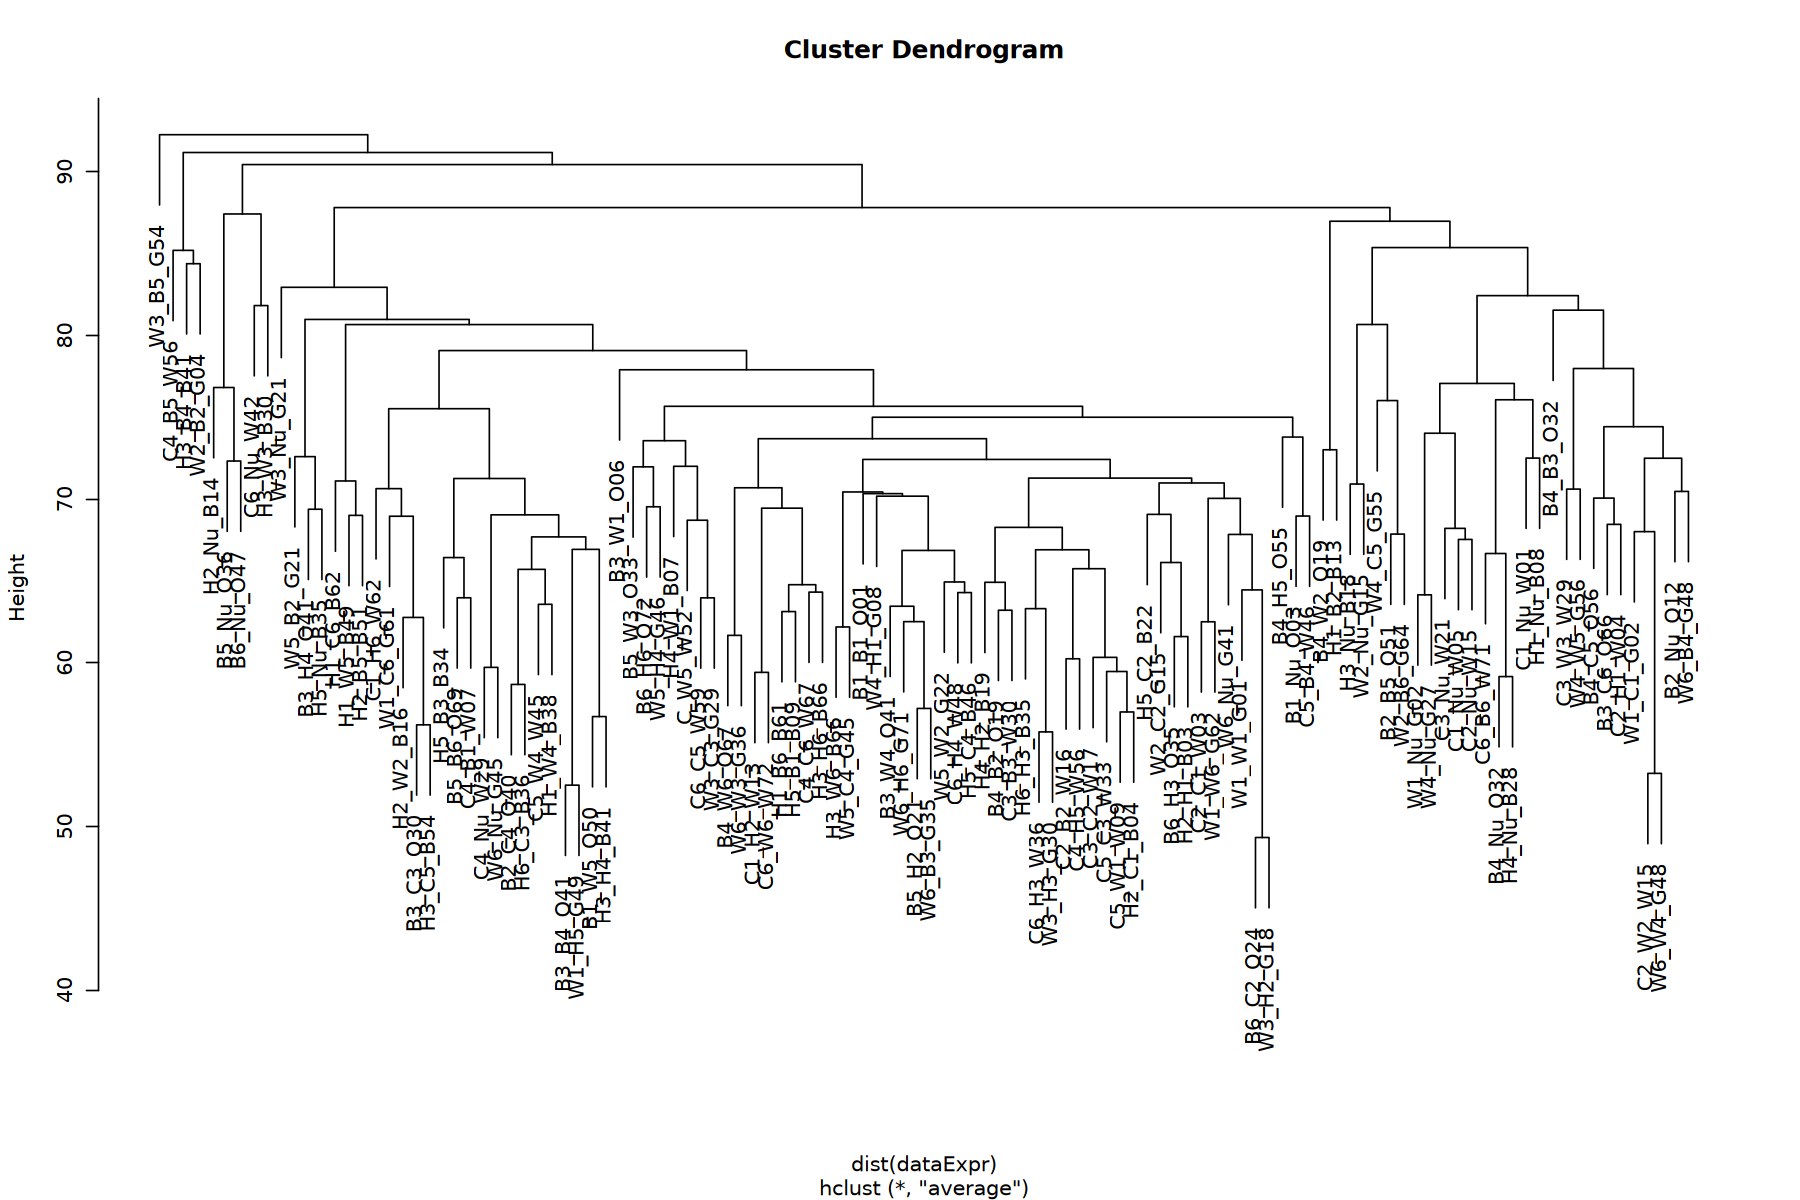

In [86]:
options(repr.plot.width = 15, repr.plot.height = 10)

sampleTree <- hclust(dist(dataExpr), method = "average")
plot(sampleTree)

no obvious outliers to remove

In [87]:
# QC check again
gsg <- goodSamplesGenes(dataExpr, verbose = 3)
if (!gsg$allOK) {
  dataExpr <- dataExpr[gsg$goodSamples, gsg$goodGenes]
}

gsg$allOK

 Flagging genes and samples with too many missing values...
  ..step 1


[1] TRUE

### meta data
could add phenotypic data to this ...

In [88]:
meta <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/metaData/sample_metaData.csv') 

# setting samples as rownames and deleting col from df
rownames(meta) <- meta$Sample
meta <- meta[, !colnames(meta) %in% "Sample"]

# removing same samples as dataExpr
meta <- meta[rownames(meta) %in% rownames(dataExpr), ]

head(meta)
dim(meta) # 114 samples

,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>
B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1
B1_Nu_O03,both,warm,hypoxic,1,NA,NA,NA,NA
B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5
B2_B5_O51,both,warm,hypoxic,2,both,warm,hypoxic,5
B2_C4_O40,both,warm,hypoxic,2,control,ambient,normoxic,4
B2_Nu_O12,both,warm,hypoxic,2,NA,NA,NA,NA


[1] 114   8

In [89]:
# double checking the samples in rownames are the same
all(rownames(meta) == rownames(dataExpr))

[1] TRUE

### 2. simple WGCNA network construction and module identification
start with simple, can progress to consensus if deemed necessary

In [90]:
# final QC check
gsg <- goodSamplesGenes(dataExpr, verbose = 3)
if (!gsg$allOK) {
  dataExpr <- dataExpr[gsg$goodSamples, gsg$goodGenes]
}

gsg$allOK

 Flagging genes and samples with too many missing values...
  ..step 1


[1] TRUE

### A. choose soft thresholding power (β)
analysis of network topology

In [91]:
powers <- c(1:20)
sft <- pickSoftThreshold(
  dataExpr,
  powerVector = powers,
  networkType = "signed",
  verbose = 5
)


pickSoftThreshold: will use block size 2268.
 pickSoftThreshold: calculating connectivity for given powers...
   ..working on genes 1 through 2268 of 19724
   ..working on genes 2269 through 4536 of 19724
   ..working on genes 4537 through 6804 of 19724
   ..working on genes 6805 through 9072 of 19724
   ..working on genes 9073 through 11340 of 19724
   ..working on genes 11341 through 13608 of 19724
   ..working on genes 13609 through 15876 of 19724
   ..working on genes 15877 through 18144 of 19724
   ..working on genes 18145 through 19724 of 19724
   Power SFT.R.sq slope truncated.R.sq mean.k. median.k. max.k.
1      1   0.0291  9.79          0.916 9930.00  9930.000  10400
2      2   0.0523  5.92          0.917 5130.00  5100.000   5740
3      3   0.1770 -5.52          0.793 2720.00  2670.000   3430
4      4   0.6500 -6.90          0.885 1480.00  1430.000   2190
5      5   0.8120 -5.84          0.925  826.00   781.000   1480
6      6   0.8700 -4.73          0.928  475.00   435.000   

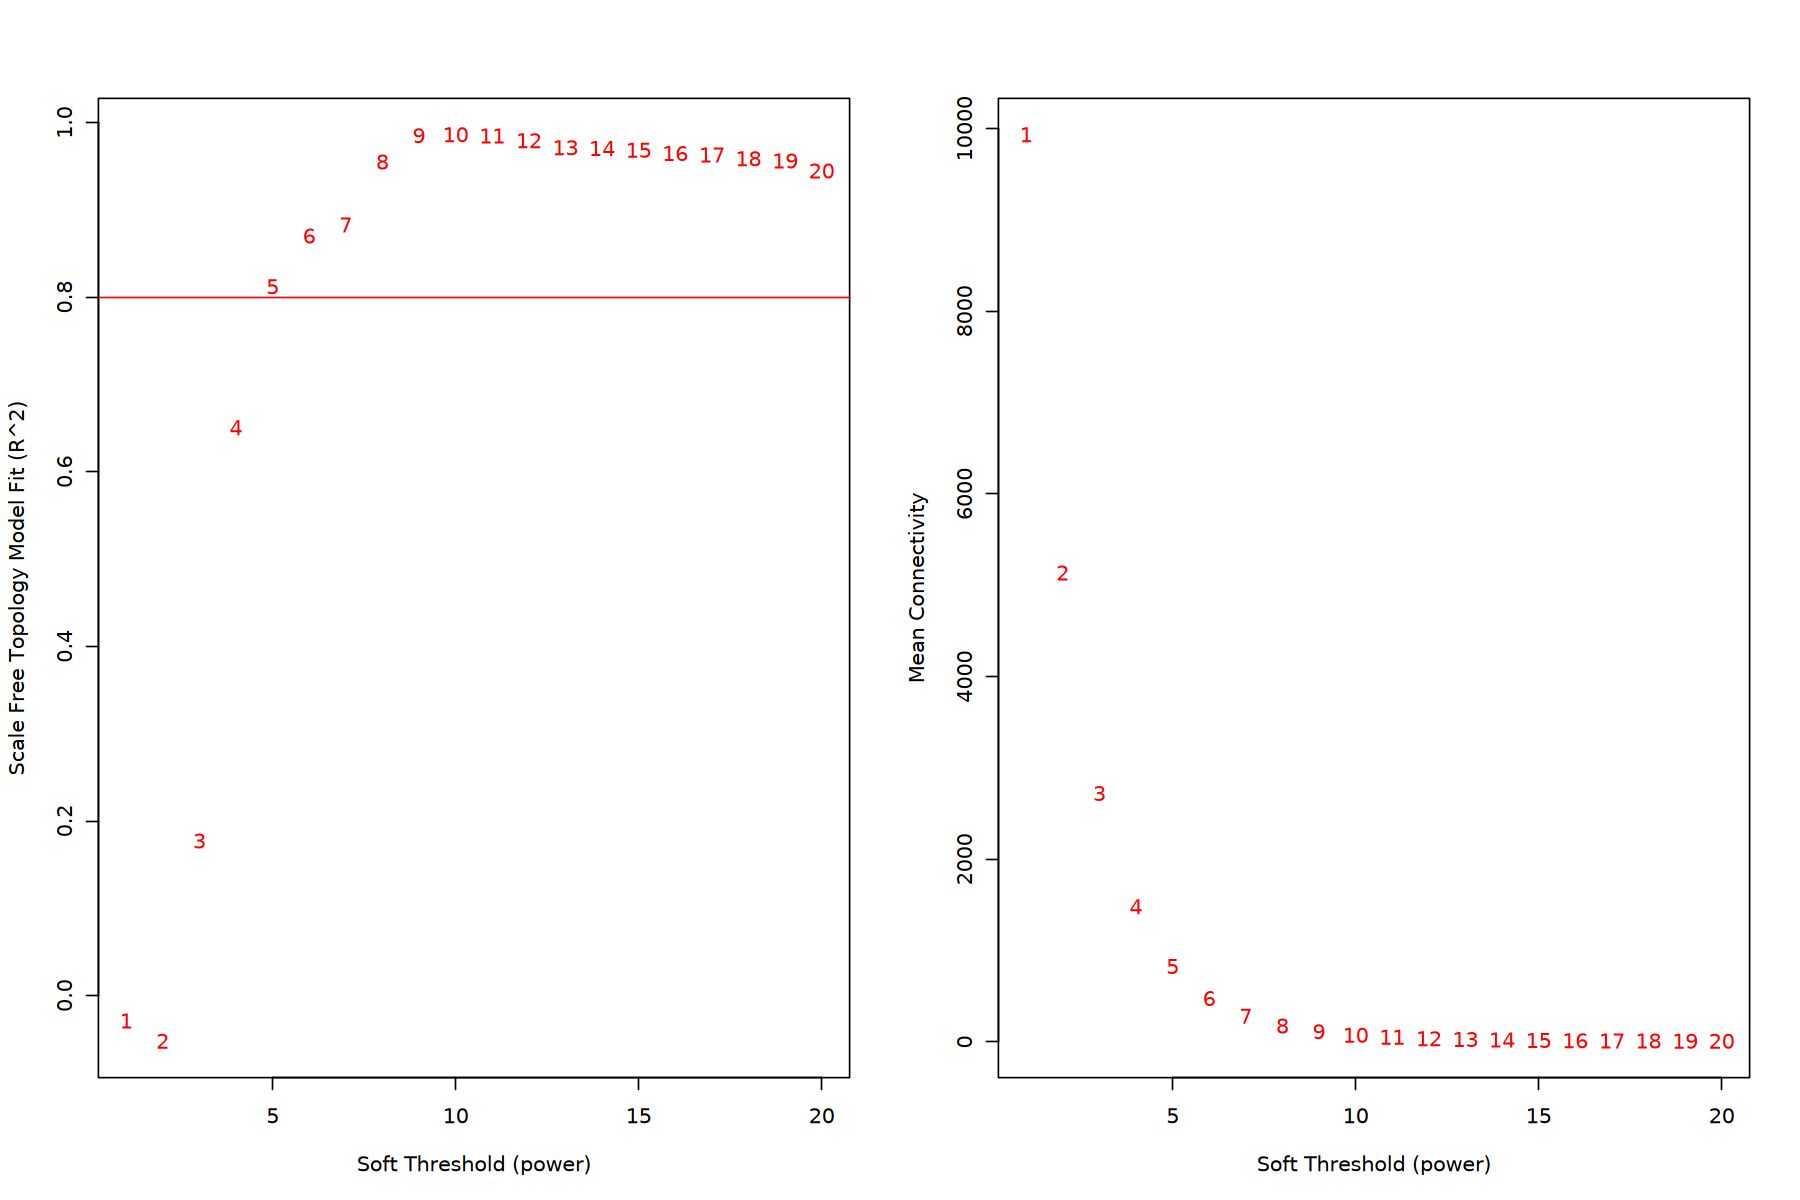

In [92]:
par(mfrow = c(1,2))
plot(
  sft$fitIndices[,1],
  -sign(sft$fitIndices[,3]) * sft$fitIndices[,2],
  xlab = "Soft Threshold (power)",
  ylab = "Scale Free Topology Model Fit (R^2)",
  type = "n"
)
text(
  sft$fitIndices[,1],
  -sign(sft$fitIndices[,3]) * sft$fitIndices[,2],
  labels = powers,
  col = "red"
)
abline(h = 0.8, col = "red")

plot(
  sft$fitIndices[,1],
  sft$fitIndices[,5],
  xlab = "Soft Threshold (power)",
  ylab = "Mean Connectivity",
  type = "n"
)
text(
  sft$fitIndices[,1],
  sft$fitIndices[,5],
  labels = powers,
  col = "red"
)


#### left plot - scale-free topology
the red line is where R^2 is 0.8 - you want the lowest power that reaches this - 13 is just above 0.8 and anything after 13 plateaus

#### right plot - mean connectivity
connectivity should not collapse to 0 - by power ~14, the connectivity approaches 0

based on this, I think power of 5 should be appropriate

### B. co-expression similarity and adjacency

creating adjacency matrix

In [93]:
softPower <- 5

calculate co-expression adjacency using soft threshold power of 5

doing signed like the phase 2 vs. phase 2 analysis

In [94]:
# signed
adjacency_sign <- adjacency(dataExpr, power = softPower, type = 'signed') 
head(adjacency_sign)

,LOC144621260,LOC144621269,LOC111120925,LOC144621283,LOC144621276,LOC111115920,LOC144621308,LOC111112629,LOC111102827,LOC111102829,⋯,LOC144621545,LOC111110910,LOC111110817,LOC111111216,LOC111111215,LOC111111213,LOC111114497,LOC111114498,LOC111112304,LOC144621888
LOC144621260,1.00000000,0.19266727,0.21389130,0.01318264,0.027905484,0.021387817,0.02707227,0.03877573,0.073754495,0.03522757,⋯,0.02017168,0.03323255,0.04913732,0.06881321,0.09154508,0.02509032,0.009543595,0.01219920,0.0572081476,0.023104958
LOC144621269,0.19266727,1.00000000,0.06628531,0.02931460,0.053020199,0.006082470,0.09550741,0.04463114,0.217086657,0.09865868,⋯,0.01632015,0.04880103,0.04783461,0.04591067,0.07376343,0.03466440,0.016977502,0.03563970,0.0276376771,0.020274270
LOC111120925,0.21389130,0.06628531,1.00000000,0.03270511,0.039238504,0.017699757,0.02948092,0.04413460,0.092865606,0.02901516,⋯,0.02825064,0.01628031,0.02992904,0.01743019,0.01522199,0.04940150,0.015727568,0.05148867,0.0215914355,0.046546464
LOC144621283,0.01318264,0.02931460,0.03270511,1.00000000,0.265855325,0.010776867,0.01915052,0.04025681,0.003014941,0.02607189,⋯,0.03843709,0.03268532,0.02054604,0.06528471,0.03843271,0.08524336,0.162431904,0.01133978,0.0004724005,0.011605756
LOC144621276,0.02790548,0.05302020,0.03923850,0.26585532,1.000000000,0.005850535,0.01657426,0.04931593,0.005788511,0.03367316,⋯,0.01464594,0.04437145,0.01870512,0.03806612,0.02686702,0.28726463,0.388380126,0.03354016,0.0004107557,0.008765219
LOC111115920,0.02138782,0.00608247,0.01769976,0.01077687,0.005850535,1.000000000,0.04726904,0.06621394,0.031676162,0.02179786,⋯,0.05936418,0.02003976,0.03162291,0.04435539,0.05570517,0.01313440,0.019743678,0.01973038,0.0833630134,0.139018143


### C. Topological Overlap Matrix (TOM)
transform adjacency into TOM to minimize effects of noise and spurious associations - calculate corresponding dissimilarity

In [95]:
## SIGNED
# turn adjacency into topological overlap
TOM_sign <- TOMsimilarity(adjacency_sign)
head(TOM_sign)

# calculate dissimilarity
dissTOM_sign <- 1-TOM_sign
head(dissTOM_sign)

..connectivity..
..matrix multiplication (system BLAS)..
..normalization..
..done.


1.00000000,0.14043856,0.08867062,0.04075985,0.05244498,0.04229683,0.05635304,0.04675483,0.06899053,0.05768039,⋯,0.04323088,0.04790255,0.05584116,0.04926209,0.06070086,0.04182229,0.04014383,0.04550052,0.05179920,0.04794172
0.14043856,1.00000000,0.07806349,0.05120549,0.06344403,0.03970612,0.10530891,0.06891340,0.14287728,0.11044504,⋯,0.04688859,0.07169978,0.07661805,0.06933803,0.09370492,0.06169044,0.04150328,0.06954864,0.05791331,0.05451324
0.08867062,0.07806349,1.00000000,0.04304453,0.05271071,0.04080003,0.05186911,0.05171625,0.07035452,0.05147566,⋯,0.04654831,0.04014357,0.05098978,0.04175041,0.04458614,0.04869920,0.03966792,0.06113120,0.04500438,0.05387151
0.04075985,0.05120549,0.04304453,1.00000000,0.13641279,0.04066712,0.04190948,0.05086602,0.02792255,0.04314791,⋯,0.04623806,0.05645250,0.03961502,0.06801212,0.04558977,0.08697823,0.12132950,0.03645181,0.02197409,0.04032171
0.05244498,0.06344403,0.05271071,0.13641279,1.00000000,0.04266693,0.05163448,0.06167693,0.03585140,0.05245959,⋯,0.04773419,0.06772960,0.04589102,0.08633420,0.05568391,0.13487732,0.15586263,0.04814201,0.02163688,0.04449887
0.04229683,0.03970612,0.04080003,0.04066712,0.04266693,1.00000000,0.03597214,0.03717896,0.04390622,0.03246092,⋯,0.04224236,0.03553163,0.04048916,0.04123546,0.04352320,0.03496495,0.04697157,0.03520233,0.05658869,0.04421000


0.0000000,0.8595614,0.9113294,0.9592401,0.9475550,0.9577032,0.9436470,0.9532452,0.9310095,0.9423196,⋯,0.9567691,0.9520975,0.9441588,0.9507379,0.9392991,0.9581777,0.9598562,0.9544995,0.9482008,0.9520583
0.8595614,0.0000000,0.9219365,0.9487945,0.9365560,0.9602939,0.8946911,0.9310866,0.8571227,0.8895550,⋯,0.9531114,0.9283002,0.9233820,0.9306620,0.9062951,0.9383096,0.9584967,0.9304514,0.9420867,0.9454868
0.9113294,0.9219365,0.0000000,0.9569555,0.9472893,0.9592000,0.9481309,0.9482838,0.9296455,0.9485243,⋯,0.9534517,0.9598564,0.9490102,0.9582496,0.9554139,0.9513008,0.9603321,0.9388688,0.9549956,0.9461285
0.9592401,0.9487945,0.9569555,0.0000000,0.8635872,0.9593329,0.9580905,0.9491340,0.9720775,0.9568521,⋯,0.9537619,0.9435475,0.9603850,0.9319879,0.9544102,0.9130218,0.8786705,0.9635482,0.9780259,0.9596783
0.9475550,0.9365560,0.9472893,0.8635872,0.0000000,0.9573331,0.9483655,0.9383231,0.9641486,0.9475404,⋯,0.9522658,0.9322704,0.9541090,0.9136658,0.9443161,0.8651227,0.8441374,0.9518580,0.9783631,0.9555011
0.9577032,0.9602939,0.9592000,0.9593329,0.9573331,0.0000000,0.9640279,0.9628210,0.9560938,0.9675391,⋯,0.9577576,0.9644684,0.9595108,0.9587645,0.9564768,0.9650350,0.9530284,0.9647977,0.9434113,0.9557900


### D. Call the hierarchical clustering function - plot the tree
hierarchical clustering tree (dendrogram) of genes

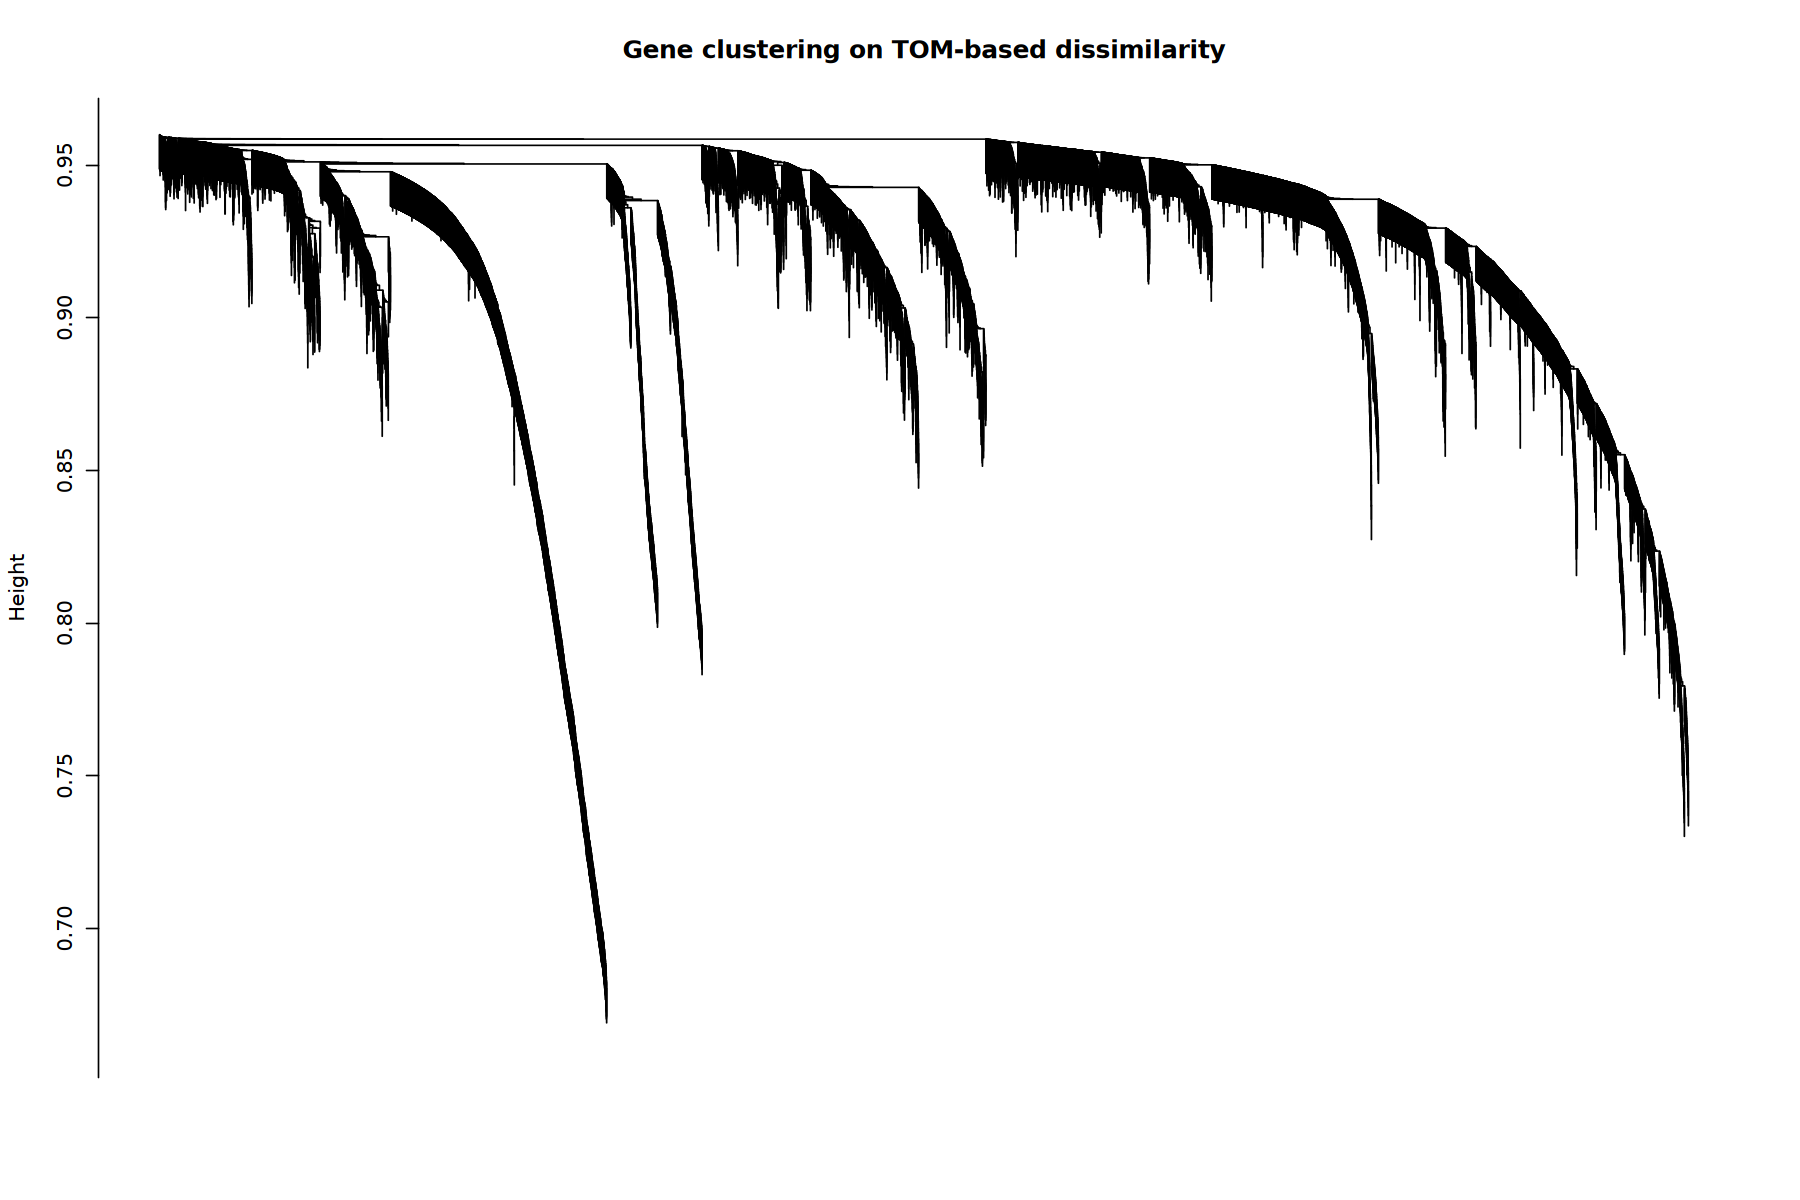

In [96]:
# call hierarchical clustering function
geneTree_sign = hclust(as.dist(dissTOM_sign), method = "average")

# plot the dendrogram
plot(geneTree_sign, xlab="", sub="", main = "Gene clustering on TOM-based dissimilarity",labels = FALSE, hang = 0.04)

each leaf (short vertical line) corresponds to a gene - branches group together densely interconnected, highly co-expressed genes

module identification = cutting branches off the dendrogram

### E. module identification

set minimum module size - this is the smallest number of genes allowed to be put into a module 

then use Dynamic Tree Cut which is the default method for branch cutting and module detection

In [97]:
# would like large modules, so we set the minimum module size relatively high:
minModuleSize <- 100

## SIGNED
# Module identification using dynamic tree cut:
dynamicMods_sign <- cutreeDynamic(dendro = geneTree_sign, distM = dissTOM_sign, 
                             deepSplit = 2, pamRespectsDendro = FALSE,
                             minClusterSize = minModuleSize)
table(dynamicMods_sign) # number of genes per module

 ..cutHeight not given, setting it to 0.958  ===>  99% of the (truncated) height range in dendro.
 ..done.


dynamicMods_sign
   1    2    3    4    5    6    7    8    9   10   11 
6229 3754 2932 1918 1183  856  791  776  476  463  346 

11 modules generated

convert numeric network to colors and plots dendrogram:

dynamicColors_sign
      black        blue       brown       green greenyellow     magenta 
        791        3754        2932        1183         346         476 
       pink      purple         red   turquoise      yellow 
        776         463         856        6229        1918 

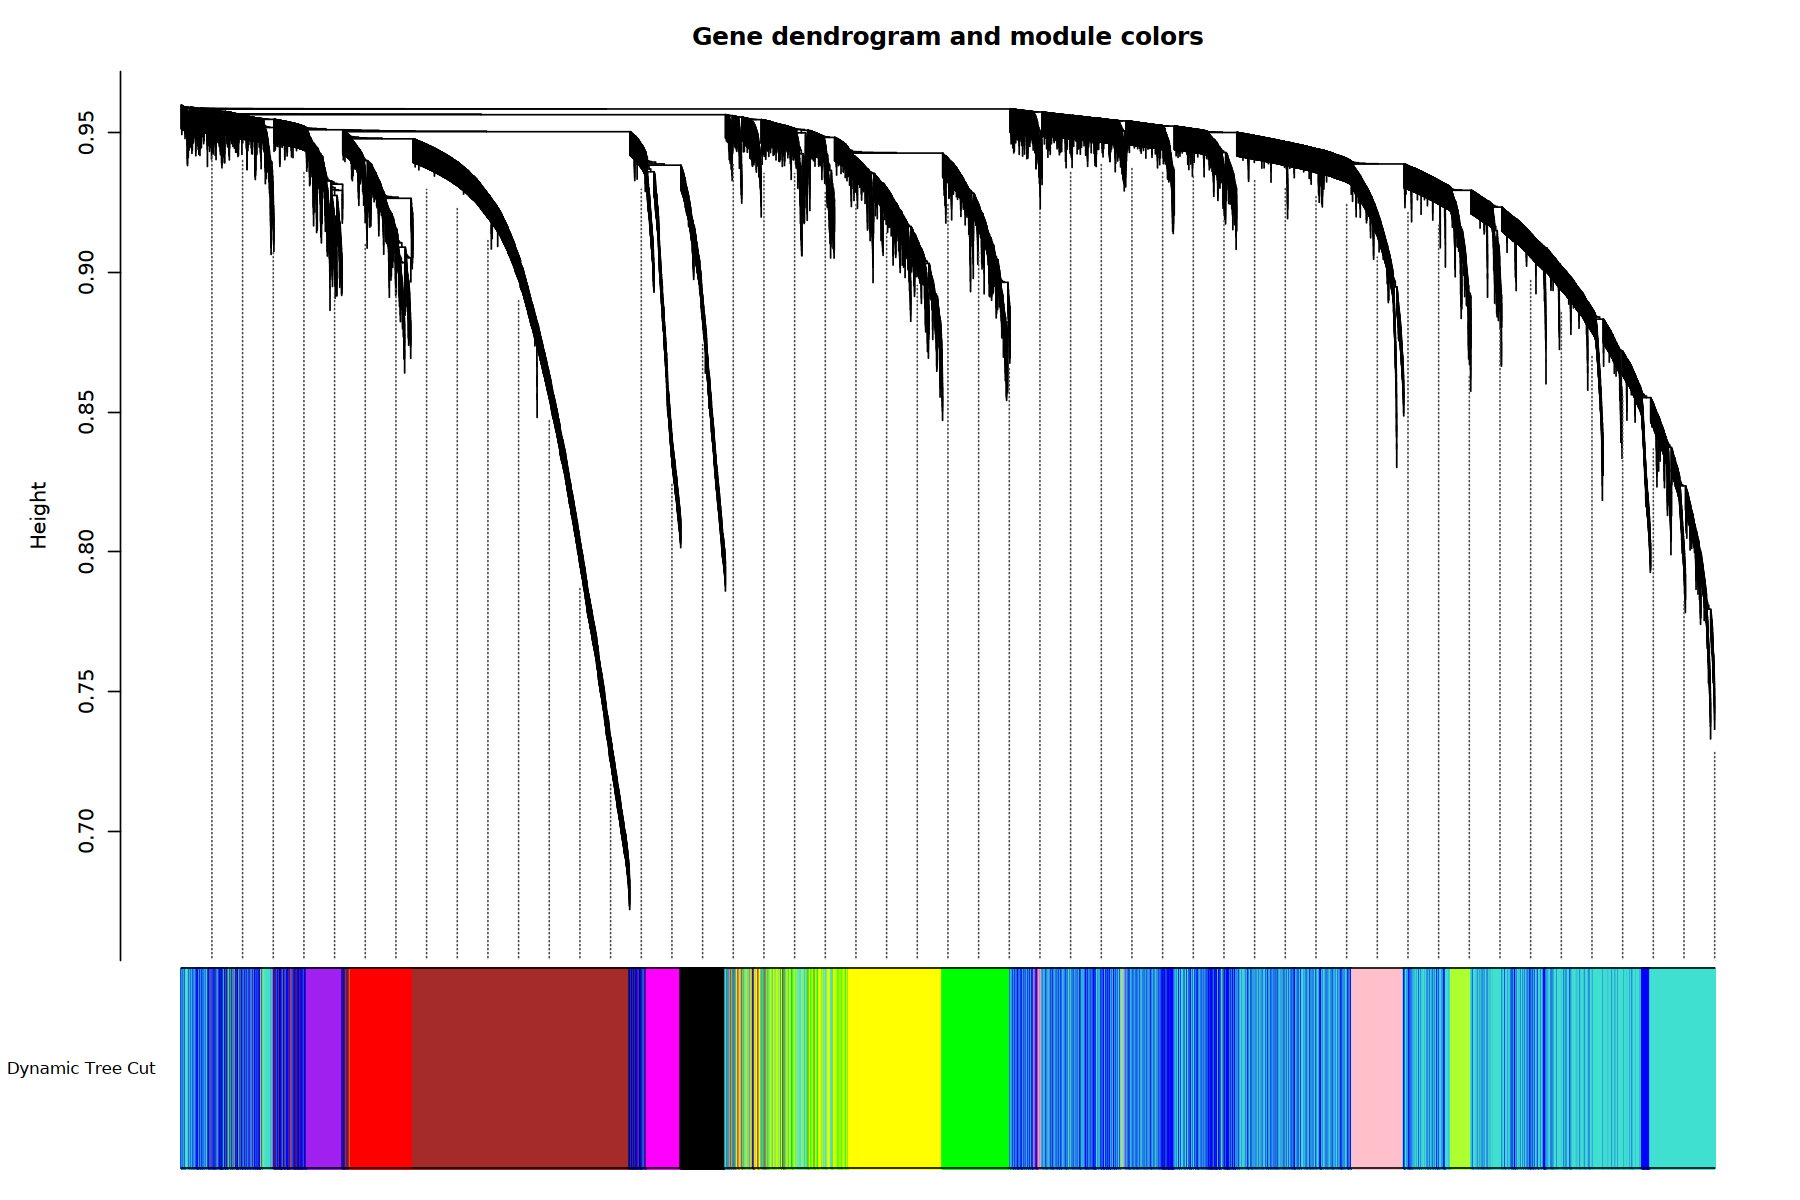

In [98]:
## SIGNED
# Convert numeric lables into colors
dynamicColors_sign <- labels2colors(dynamicMods_sign)
table(dynamicColors_sign)

# Plot the dendrogram and colors underneath
plotDendroAndColors(geneTree_sign, dynamicColors_sign, "Dynamic Tree Cut",
                    dendroLabels = FALSE, hang = 0.03,
                    addGuide = TRUE, guideHang = 0.05,
                    main = "Gene dendrogram and module colors")


### F. merging modules whose GE profiles are similar

this is based on eigengenes, which is the first principal component of a given a gene expression matrix/module that acts as a representative summary profile for a gene module or cluster

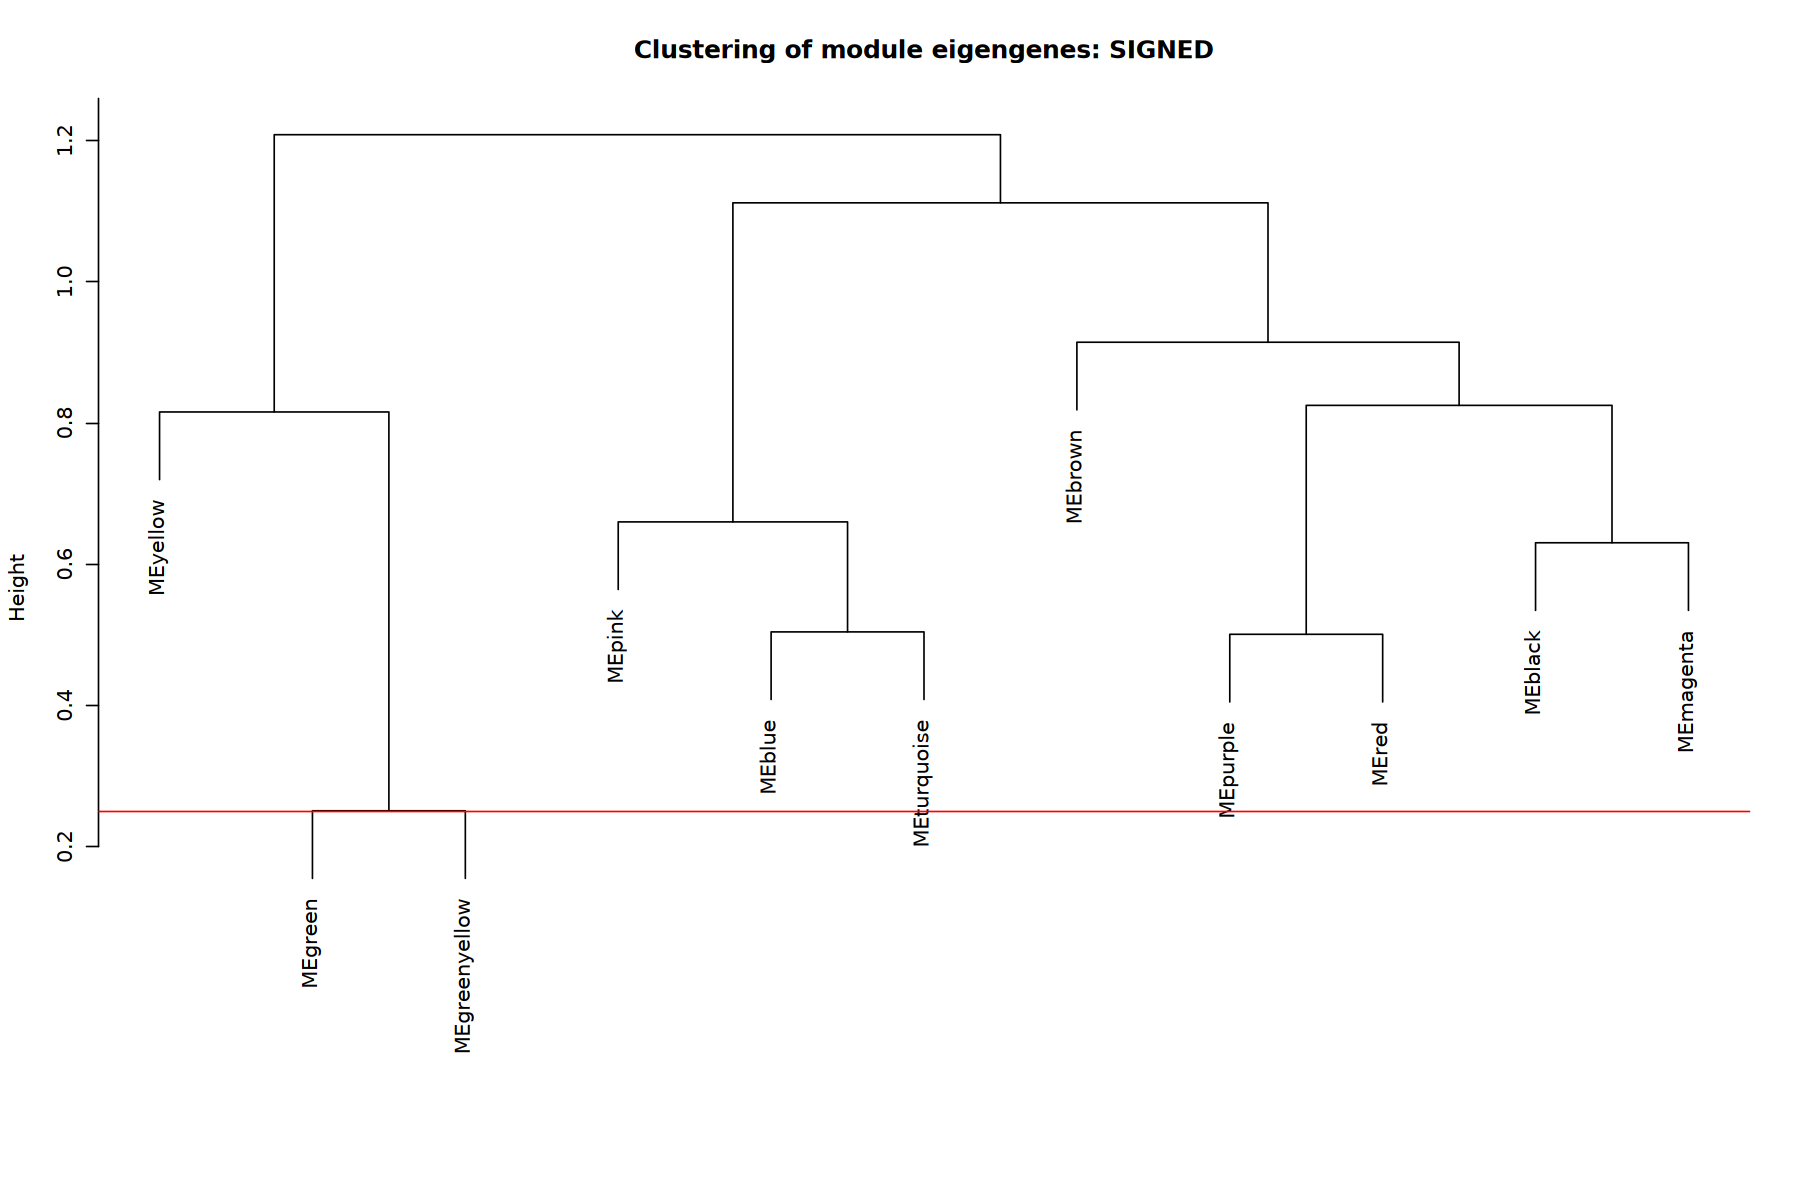

In [99]:
## SIGNED
# Calculate eigengenes
MEList_sign <- moduleEigengenes(dataExpr, colors = dynamicColors_sign)
MEs_sign <- MEList_sign$eigengenes

# Calculate dissimilarity of module eigengenes
MEDiss_sign <- 1-cor(MEs_sign)

# Cluster module eigengenes
METree_sign <- hclust(as.dist(MEDiss_sign), method = "average")

# Plot the result

# height cutoff of 0.25 - corresponds to a correlation of 0.75 to merge
MEDissThres <- 0.25

# Plot the cut line into the dendrogram
plot(METree_sign, main = "Clustering of module eigengenes: SIGNED", xlab = "", sub = "")
abline(h=MEDissThres, col = "red")

any branch with more than 75% correlation are related and will be merged - so green and greenyellow modules will be merged (but it's right on the line, so maybe not)

 mergeCloseModules: Merging modules whose distance is less than 0.25
   multiSetMEs: Calculating module MEs.
     Working on set 1 ...
     moduleEigengenes: Calculating 11 module eigengenes in given set.
   Calculating new MEs...
   multiSetMEs: Calculating module MEs.
     Working on set 1 ...
     moduleEigengenes: Calculating 11 module eigengenes in given set.


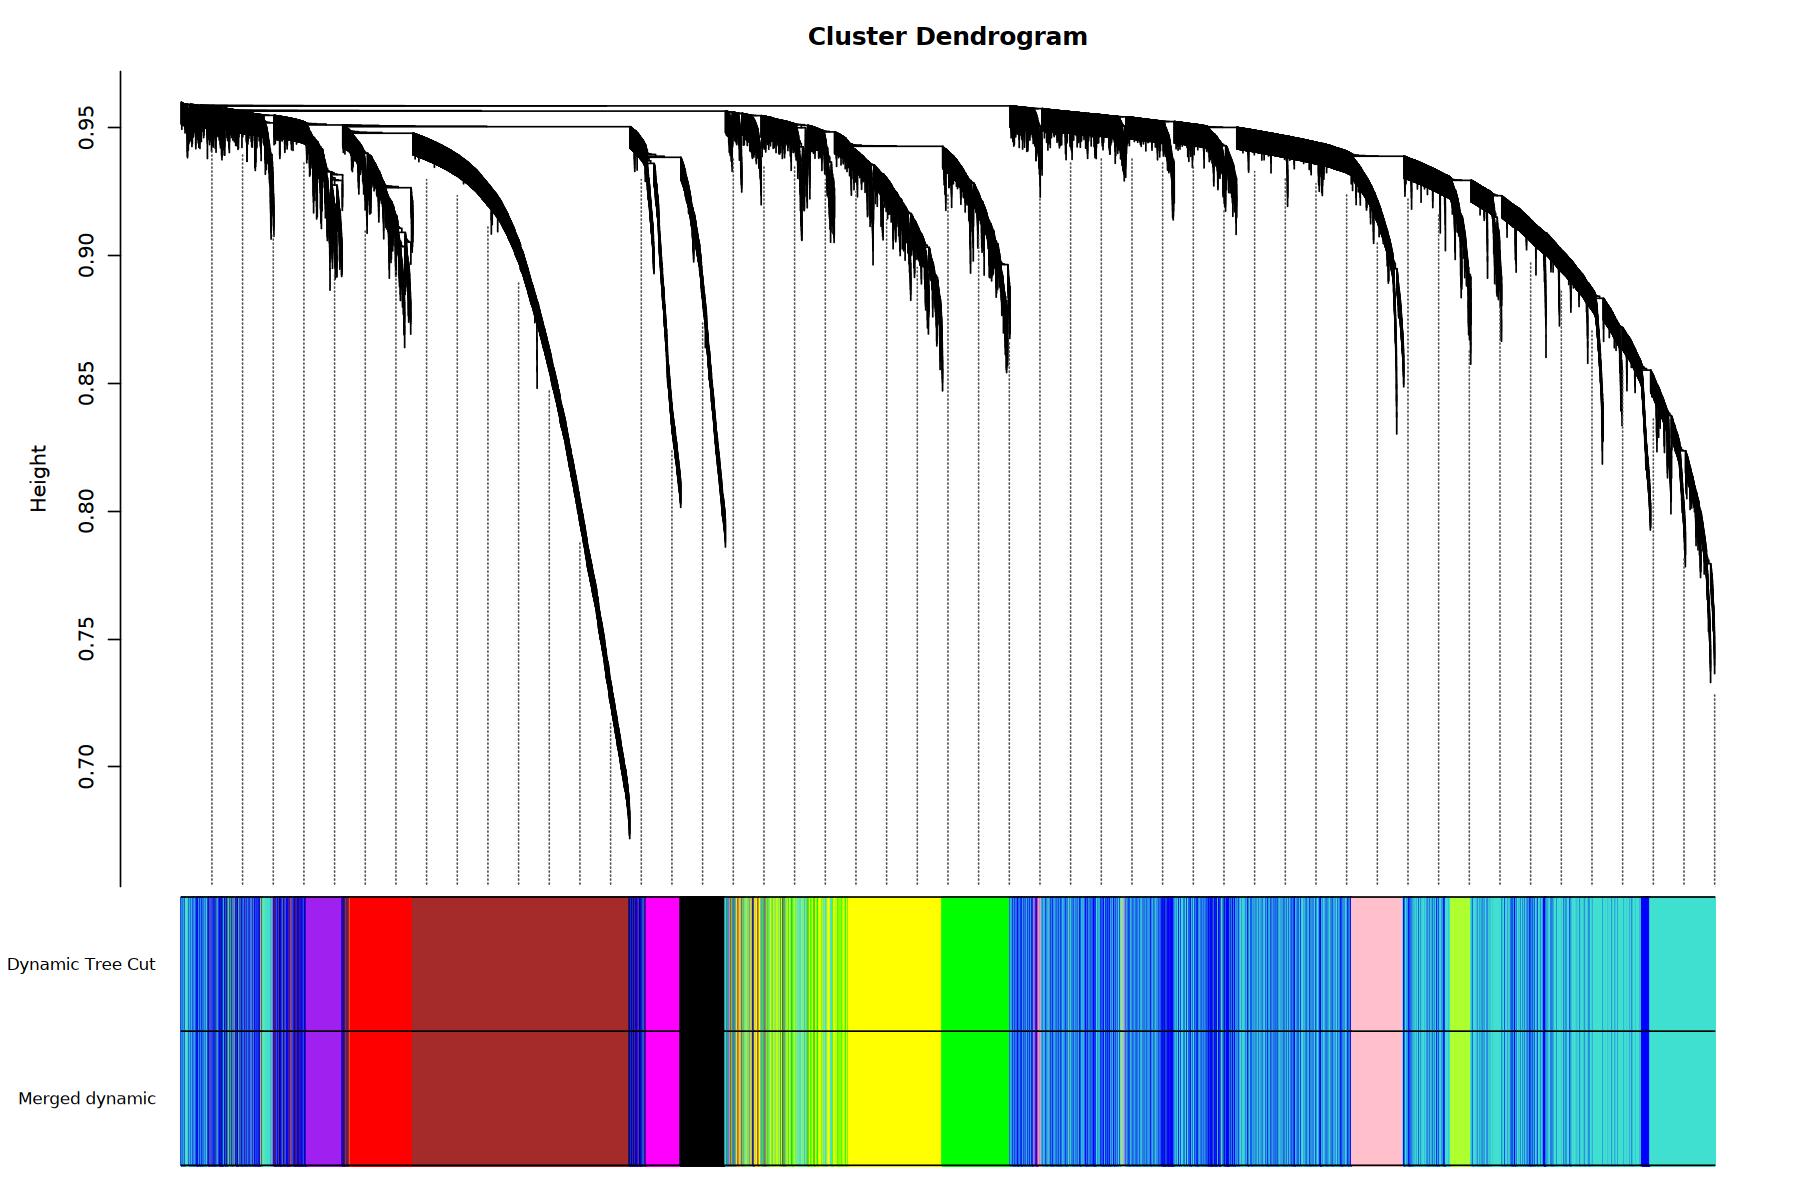

In [100]:
## SIGNED
# Call an automatic merging function
merge_sign <- mergeCloseModules(dataExpr, dynamicColors_sign, cutHeight = MEDissThres, verbose = 3)

# The merged module colors
mergedColors_sign <- merge_sign$colors

# Eigengenes of the new merged modules:
mergedMEs_sign <- merge_sign$newMEs

# plot merged module colors
plotDendroAndColors(geneTree_sign, cbind(dynamicColors_sign, mergedColors_sign), 
                    c("Dynamic Tree Cut", "Merged dynamic"),
                    dendroLabels = FALSE, hang = 0.03,
                    addGuide = TRUE, guideHang = 0.05)

In [102]:
table(mergedColors_sign)

mergedColors_sign
      black        blue       brown       green greenyellow     magenta 
        791        3754        2932        1183         346         476 
       pink      purple         red   turquoise      yellow 
        776         463         856        6229        1918 

11 modules ranging from 346 - 6229 genes

In [103]:
# Recalculate MEs (module eigengenes) with color labels

MEs0 <- moduleEigengenes(dataExpr, mergedColors_sign)$eigengenes # create module eigengenes

MEs <- orderMEs(MEs0) # order so more similar modules are closer together
head(MEs)

,MEyellow,MEgreen,MEgreenyellow,MEpink,MEblue,MEturquoise,MEbrown,MEpurple,MEred,MEblack,MEmagenta
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
B1_B1_O01,0.03566661,0.022677996,-0.01049978,0.02686711,-0.038702859,-0.028127264,-0.059874401,0.004774668,-0.005089303,0.09279347,-0.01581767
B1_Nu_O03,0.06234248,0.002044744,-0.01163607,-0.18844656,-0.105132078,0.026558259,-0.062962221,-0.010683464,0.002621254,-0.05927394,-0.03342253
B1_W5_O50,-0.01980661,-0.098597769,-0.04174799,-0.01578871,0.009260785,0.045289246,0.009446769,0.063351238,-0.068319657,-0.07723555,-0.04364456
B2_B5_O51,-0.04999356,-0.173983516,-0.12159166,-0.08105570,-0.003053896,0.052328441,0.037073193,0.136240310,0.029527035,0.16390164,0.10169878
B2_C4_O40,0.03068045,0.073926877,0.09662611,0.01658701,-0.005764699,0.032204740,-0.012931107,-0.103336486,-0.090922592,-0.05543699,-0.02902669
B2_Nu_O12,0.05964174,0.024681068,-0.03489202,-0.18209404,-0.054722574,0.006462196,0.217113274,-0.046858127,-0.017092288,-0.04740375,-0.02847034


In [104]:
write.csv(MEs, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/compare_phases/outputs/wgcnaAll_ModuleEigengenes.csv')